<a href="https://colab.research.google.com/github/Lu1sV1rus/Estocasticos/blob/main/Descomposici%C3%B3n_Can%C3%B3nica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p><font size="6">Descomposición Canónica/font></p>
<font color="tomato"></font>

---

<p><font size="3">
En una Notebook de Jupyter realice lo siguiente:
<br>1. Escriba la matriz P de la imagen anexa y dibuje su diagrama de transiciones.
<br>2. Determine si la matriz tiene o no distribución límite.
<br>3. Escriba la descomposición canónica de la matriz, determine el límite de la potencia n-esima y compare contra las distribuciones límite de las submatrices.
<br>4. Escriba un programa que encuentre la descomposición canónica de una matriz dada.</b></font></p>

<hr size="2" ">


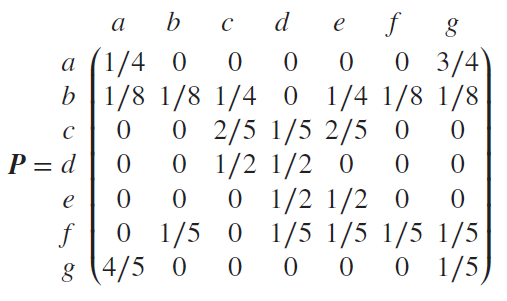

---

<p><font size="4">Librerías para el Análisis de Cadenas de Markov</font></p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">import numpy as np</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Manejo de la matriz de transición $P$ y cálculo de potencias $P^n$.</font>
</p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">import networkx as nx</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Modelado de la cadena como un grafo para identificar estados transitorios y recurrentes.</font>
</p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">import matplotlib.pyplot as plt</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Permite la visualización del grafo de la cadena y la convergencia de las probabilidades.</font>
</p>

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

<p><font size="4">Definición de la Matriz de Transición P</font></p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">np.array([[]])</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Se construye la matriz estocástica de 7x7 que rige el comportamiento del sistema.</font>
</p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">Estructura de la Matriz</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Contiene las probabilidades de transición donde P[i,j] representa la probabilidad de pasar del estado <i>i</i> al estado <i>j</i>.</font>
</p>


In [ ]:
# Escriba la matriz P
P = np.array([[1/4, 0,   0,   0,   0,   0,   3/4],
              [1/8, 1/8, 1/4, 0,   1/4, 1/8, 1/8],
              [0,   0,   2/5, 1/5, 2/5, 0,   0  ],
              [0,   0,   1/2, 1/2, 0,   0,   0  ],
              [0,   0,   0,   1/2, 1/2, 0,   0  ],
              [0,   1/5, 0,   1/5, 1/5, 1/5, 1/5],
              [4/5, 0,   0,   0,   0,   0,   1/5]])

<p><font size="4">Visualización del Diagrama de Transiciones</font></p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">nx.from_numpy_array(P, create_using=nx.DiGraph)</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Convierte la matriz numérica en un objeto de grafo dirigido para representar las transiciones.</font>
</p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">nx.relabel_nodes(G, dict(enumerate('ABCDEFG')))</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Asigna etiquetas alfabéticas a los nodos para facilitar la lectura del diagrama.</font>
</p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">nx.circular_layout(G)</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Organiza los estados en un círculo para evitar que las aristas se encimen demasiado.</font>
</p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">nx.draw_networkx_nodes()</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Dibuja los nodos del sistema con un tamaño y color específico para resaltar los estados.</font>
</p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">nx.draw_networkx_labels()</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Renderiza los nombres de los nodos (A, B, C...) dentro de los círculos en negritas.</font>
</p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">nx.draw_networkx_edges()</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Traza las flechas de transición, ajustando la curvatura y el tamaño de la punta para mayor claridad.</font>
</p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">edge_labels = {(u, v): f"{d['weight']:.2f}"...}</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Extrae los pesos de la matriz y los formatea a dos decimales para mostrarlos en el diagrama.</font>
</p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">nx.draw_networkx_edge_labels()</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Añade los valores de probabilidad de la matriz como etiquetas sobre cada flecha de transición.</font>
</p>

In [ ]:
# Diagrama de Transiciones
def diagrama(P):
  G = nx.from_numpy_array(P, create_using=nx.DiGraph)       # Creamos un digrafo
  G = nx.relabel_nodes(G, dict(enumerate('ABCDEFGHIJK')))

  plt.figure(figsize=(8, 6))
  pos = nx.circular_layout(G)

  nx.draw_networkx_nodes(G, pos, node_size=600, node_color='skyblue')
  nx.draw_networkx_labels(G, pos, font_weight='bold')
  nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=20,
                        edge_color='gray', connectionstyle='arc3,rad=0.1')

  edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
  nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, label_pos=0.3)
  plt.show()

  return G

<p><font size="4">Ejecución y Resultados del Sistema</font></p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">print(P)</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Muestra en consola la matriz numérica para verificar que los datos se ingresaron correctamente.</font>
</p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">G = diagrama(P)</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Llama a la función de dibujo y almacena el objeto de grafo para análisis posteriores de conectividad.</font>
</p>

[[0.25  0.    0.    0.    0.    0.    0.75 ]
 [0.125 0.125 0.25  0.    0.25  0.125 0.125]
 [0.    0.    0.4   0.2   0.4   0.    0.   ]
 [0.    0.    0.5   0.5   0.    0.    0.   ]
 [0.    0.    0.    0.5   0.5   0.    0.   ]
 [0.    0.2   0.    0.2   0.2   0.2   0.2  ]
 [0.8   0.    0.    0.    0.    0.    0.2  ]]


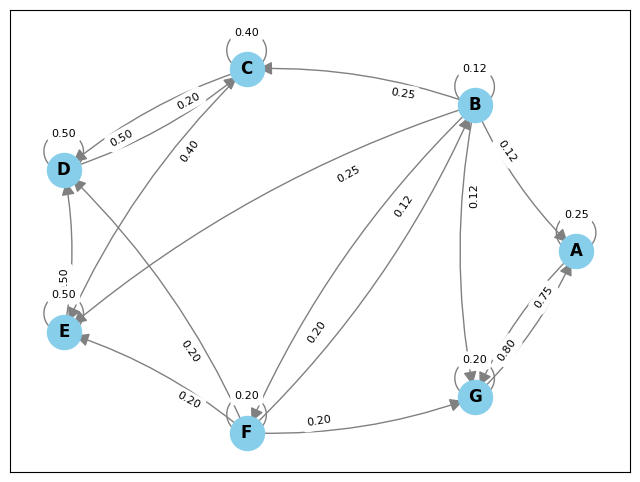

In [ ]:
# Escriba la matriz P de la imagen anexa y dibuje su diagrama de transiciones
print(P)
G=diagrama(P)

<p><font size="4">Determinación de la Distribución Límite</font></p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">nx.is_strongly_connected(K)</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Verifica si la cadena es irreducible, es decir, si es posible llegar de cualquier estado a cualquier otro.</font>
</p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">nx.strongly_connected_components(K)</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Identifica las clases de comunicación del sistema para agrupar los estados que se relacionan entre sí.</font>
</p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">if irr: ... else: ...</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Evalúa la unicidad de la distribución; si no es irreducible, el límite dependerá de dónde inicie el proceso.</font>
</p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">print(f"Clase {i+1}: {cla}")</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Desglosa la composición de cada clase encontrada, facilitando la detección de estados transitorios o absorbentes.</font>
</p>

In [ ]:
# Determine si la matriz tiene o no distribución límite.
def dislim(K):
  # Se puede reducir?
  irr = nx.is_strongly_connected(K)

  # Clase
  cla= list(nx.strongly_connected_components(K))

  if irr:
    print("La cadena tiene distribucion limite unica .")
  else:
    print("La cadena tiene distribucion limite, pero el resultado final depende del estado inicial.")

  print(f"\n¿Es irreducible?: {irr}")
  print(f"\nNumero de clases: {len(cla)}")
  for i, cla in enumerate(cla):
      print(f" Clase {i+1}: {cla}")

  return irr

<p><font size="4">Análisis de Convergencia del Sistema</font></p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">limite = dislim(G)</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Ejecuta el análisis de conectividad sobre el grafo para confirmar si la cadena convergerá a un estado estable único.</font>
</p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">Variable "limite"</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Almacena el valor booleano resultante para condicionar cálculos posteriores como la potencia n-ésima de la matriz.</font>
</p>

In [ ]:
# Determine si la matriz tiene o no distribución límite.
limite=dislim(G)

La cadena tiene distribucion limite, pero el resultado final depende del estado inicial.

¿Es irreducible?: False

Numero de clases: 3
 Clase 1: {'A', 'G'}
 Clase 2: {'E', 'D', 'C'}
 Clase 3: {'F', 'B'}


<p><font size="4">Descomposición Canónica y Submatrices</font></font></p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">np.linalg.matrix_power(P, 100)</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Calcula una potencia elevada de la matriz para aproximar el comportamiento de la cadena a largo plazo ($P^\infty$).</font>
</p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">nx.attracting_components(G)</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Identifica los componentes atraientes del grafo, que corresponden a las clases de estados recurrentes.</font>
</p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">np.ix_(snum, snum)</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Realiza un indexado avanzado para extraer submatrices específicas asociadas a cada clase recurrente.</font>
</p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">np.linalg.lstsq(A, b)</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Resuelve el sistema de ecuaciones lineales para encontrar la distribución invariante local de cada submatriz.</font>
</p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">Comparativa de Valores</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Contrasta los resultados obtenidos mediante la potencia $n$-ésima frente a la distribución límite calculada analíticamente.</font>
</p>

In [ ]:
def acanonica(P, G):
  P_inf = np.linalg.matrix_power(P, 100)

  nombres_nodos = list(G.nodes)
  ntxt = {i: nombres_nodos[i] for i in range(len(nombres_nodos))} # nombres (A,B) a numeros (0,1)
  nnum = {v: k for k, v in ntxt.items()}

  clases_rec = list(nx.attracting_components(G))

  print("Canonica")
  print(f"Recurrentes: {clases_rec}")
  print("\nP^inf")
  print(np.round(P_inf, 4))
  print("\nSubMatrices")

  for i, clase in enumerate(clases_rec):
    stxt = list(clase)  # Convertir nombres a numeros
    snum = [nnum[n] for n in stxt]
    n = len(snum)

    psub = P[np.ix_(snum, snum)]  # Submatriz de transición
    A = np.append(psub.T - np.eye(n), [np.ones(n)], axis=0)
    b = np.append(np.zeros(n), [1])
    fsub = np.linalg.lstsq(A, b, rcond=None)[0]
    fpn = P_inf[snum[0], snum]

    print(f" Clase {i+1} (Estados {stxt}):")
    print(f" Valores submatriz: {np.round(fsub, 4)}")
    print(f" Valores P^inf:     {np.round(fpn, 4)}\n")

<p><font size="4">Ejecución de la Descomposición Canónica</font></p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">acanonica(P, G)</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Invoca el análisis integral para desglosar la matriz $P$ en sus componentes fundamentales y validar la convergencia.</font>
</p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">Salida de Datos</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Muestra de forma organizada los estados recurrentes, la matriz en el infinito y la comparativa de distribuciones por submatriz.</font>
</p>

In [ ]:
acanonica(P,G)

Canonica
Recurrentes: [{'A', 'G'}, {'E', 'D', 'C'}]

P^inf
[[0.5161 0.     0.     0.     0.     0.     0.4839]
 [0.172  0.     0.2222 0.2667 0.1778 0.     0.1613]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.172  0.     0.2222 0.2667 0.1778 0.     0.1613]
 [0.5161 0.     0.     0.     0.     0.     0.4839]]

SubMatrices
 Clase 1 (Estados ['A', 'G']):
 Valores submatriz: [0.5161 0.4839]
 Valores P^inf:     [0.5161 0.4839]

 Clase 2 (Estados ['E', 'D', 'C']):
 Valores submatriz: [0.2667 0.4    0.3333]
 Valores P^inf:     [0.2667 0.4    0.3333]



<p><font size="4">Programa de Descomposición Canónica Automatizado</font></p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">def descan(P):</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Función principal que encapsula todo el flujo de análisis estocástico para cualquier matriz de transición dada.</font>
</p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">diagrama(P)</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Genera la representación gráfica inicial para comprender la topología de la cadena de Markov.</font>
</p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">dislim(G)</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Determina las propiedades de conectividad y la existencia de una distribución límite única o dependiente del estado inicial.</font>
</p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">acanonica(P, G)</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Finaliza el proceso extrayendo las submatrices de los componentes atraientes y comparando su convergencia numérica.</font>
</p>

In [ ]:
# Escriba un programa que encuentre la descomposición canónica de una matriz dada.

def descan(P):
    G = diagrama(P)

    print("Distribucion limite.")
    dislim(G)

    print("\nDescomposición canonica")
    acanonica(P, G)

<p><font size="4">Ejecución total del Programa</font></p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">descan(P)</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Lleva a cabo el proceso completo: desde la visualización del grafo hasta la validación de submatrices recurrentes.</font>
</p>

<p>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="3" color="tomato">Resultados Consolidados</font>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<font size="2">&nbsp;&nbsp;&nbsp;&nbsp;Presenta en un solo flujo la clasificación de estados, el diagrama de transiciones y el análisis de convergencia final.</font>
</p>

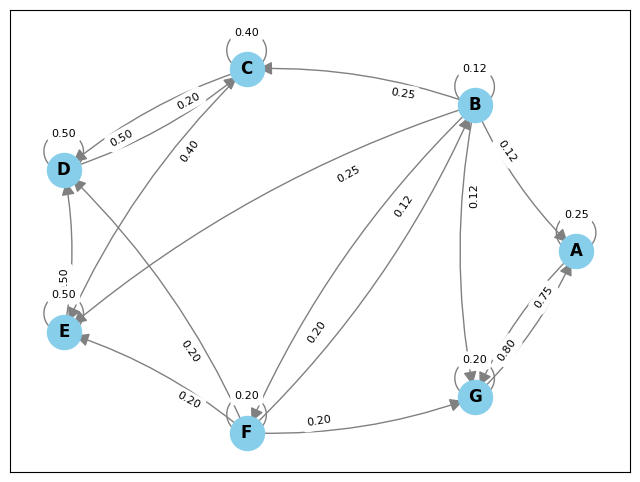

Distribucion limite.
La cadena tiene distribucion limite, pero el resultado final depende del estado inicial.

¿Es irreducible?: False

Numero de clases: 3
 Clase 1: {'A', 'G'}
 Clase 2: {'E', 'D', 'C'}
 Clase 3: {'F', 'B'}

Descomposición canonica
Canonica
Recurrentes: [{'A', 'G'}, {'E', 'D', 'C'}]

P^inf
[[0.5161 0.     0.     0.     0.     0.     0.4839]
 [0.172  0.     0.2222 0.2667 0.1778 0.     0.1613]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.172  0.     0.2222 0.2667 0.1778 0.     0.1613]
 [0.5161 0.     0.     0.     0.     0.     0.4839]]

SubMatrices
 Clase 1 (Estados ['A', 'G']):
 Valores submatriz: [0.5161 0.4839]
 Valores P^inf:     [0.5161 0.4839]

 Clase 2 (Estados ['E', 'D', 'C']):
 Valores submatriz: [0.2667 0.4    0.3333]
 Valores P^inf:     [0.2667 0.4    0.3333]



In [ ]:
descan(P)